## RISK MANAGEMENT 
MODULE 8 | LESSON 2


---


# **SYSTEMIC RISK AND BAYESIAN NETWORKS FOR TIME SERIES (DYNOTEARS)**


|  |  |
|:---|:---|
|**Reading Time** |  30 min. + up to 45 min. to run code  |
|**Prior Knowledge** | Financial contagion, Causal structure  |
|**Keywords** | Epidemic, Trigger, Complex contagion, Intervention, Cascade, Threshold, Chain effects, Interdependent networks|   

---


_In the last lesson, we discussed again how expertise can be embedded into Bayesian networks and causal structure in equity risk factors. In this lesson, we stay with both of these ideas and apply them in a Python implementation._

## **1. More Structure Learning**
In an approach that Rebonato would clearly agree with, `CausalNex` can learn network structure through a combination of experts' domain knowledge along with traditional machine learning. This union should remind you of Rebonato's push for combining some form of traditional (including frequentist) statistical analysis for the normal times (though not necessarily Normal in the statistical sense) and experts' informed and realistic subjective views.

1. Specify the structure to the extent that expert views will be incorporated as just discussed.

2. Prepare the data.

3. Apply the algorithm.

4. Visualize the structure.

5. Apply thresholding to avoid a fully connected graph. 

6. Visualize again, perform a sanity check, and add constraints if needed to correct for any logic errors or relationships that contradict domain knowledge.
Now that we have a reasonable structure, we can move to the next stage.

## **2. Simulated DYNOTEARS** ##

Let's start with some simulated data that may be a little confusing at first, but it will make the actual data seem easy: just five nodes with one potential lag node. For your convenience, we put below argument explanation comments from the function definition in the repo so you can more easily make sense of the code that follows. Make sure to read the paper and other `CausalNex` documentation (required readings for this lesson) before going further, in order to better understand the upcoming code and related concepts. The code for this simulation part was adapted from Ferreira. 

 ```python
 """

    Generates a dynamic structure model as well a dataframe representing a time series realisation of that model.
    We do checks to verify the network is stationary, and iterate until the resulting network is stationary.
    Args:
        num_nodes: number of nodes in the intra-slice structure
        n_samples: number of points to sample from the model, as a time series
        p: lag value for the dynamic structure
        degree_intra: expected degree for intra_slice nodes
        degree_inter: expected degree for inter_slice nodes
        graph_type_intra:
            - erdos-renyi: constructs a graph such that the probability of any given edge is degree / (num_nodes - 1)
            - barabasi-albert: constructs a scale-free graph from an initial connected graph of (degree / 2) nodes
            - full: constructs a fully-connected graph - degree has no effect
        graph_type_inter:
            - erdos-renyi: constructs a graph such that the probability of any given edge is degree / (num_nodes - 1)
            - full: connect all past nodes to all present nodesw_min_intra:
        w_min_intra: minimum weight on intra-slice adjacency matrix
        w_max_intra: maximum weight on intra-slice adjacency matrix
        w_min_inter: minimum weight on inter-slice adjacency matrix
        w_max_inter: maximum weight on inter-slice adjacency matrix
        w_decay: exponent of weights decay for slices that are farther apart. Default is 1.0, which implies no decay
        sem_type: {linear-gauss,linear-exp,linear-gumbel}
        noise_scale: scale parameter of noise distribution in linear SEM
        max_data_gen_trials: maximun number of attempts until obtaining a seemingly stationary model
    Returns:
        Tuple with:
        - the model created,as a Structure model
        - DataFrame representing the time series created from the model
        - Intra-slice nodes names
        - Inter-slice nodes names
"""
```

In [1]:
# GET A SIMULATED TIME SERIES

import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf  # noQA F401
from causalnex.plots import plot_structure
from causalnex.structure.data_generators import gen_stationary_dyn_net_and_df
from IPython.display import Image
from tqdm import tqdm

# silence warnings
warnings.filterwarnings("ignore")

In [2]:
# Obtain simulated structure (g), dataset sampled from g and list of node names
g, df, intra_nodes, inter_nodes = gen_stationary_dyn_net_and_df(
    num_nodes=5,
    n_samples=10000,
    p=1,
    degree_intra=3,
    degree_inter=1,
    graph_type_intra="erdos-renyi",
    graph_type_inter="erdos-renyi",
    w_min_intra=0.0,
    w_max_intra=1.0,
    w_min_inter=0.0,
    w_max_inter=1.0,
    w_decay=1.0,
    sem_type="linear-gauss",
    noise_scale=1,
    max_data_gen_trials=1000,
)

df = df[intra_nodes]
df.columns = [el.split("_")[0] for el in df.columns]
df.head()  # <<--- this is a time series data. each row is a timestamp image

,0,1,2,3,4
0,5.481996,3.884083,-2.007296,-3.298796,0.117265
1,-2.719739,-1.425442,0.500485,0.003149,-0.851404
2,2.131801,3.845917,-0.408404,-2.045945,-0.664697
3,0.470325,-0.133960,0.446721,0.777261,-0.585104
4,1.542023,2.538248,-0.747334,-0.395165,-0.427995


In [3]:
# Then you can call dynotears:
from causalnex.structure.dynotears import from_pandas_dynamic

g_learnt = from_pandas_dynamic(df, 1, lambda_w=0.1, lambda_a=0.1, w_threshold=0.1)
g_learnt

After learning the structure of our simulated graph, we make a copy and work with the copy going forward; in this way, we can modify the copy--say, raise the threshold value for which we show an arc--without modifying the original, which took time to generate. If we decide to lower the threshold for arcs after raising it, we will have already permanently deleted the arcs we wanted to recover from the copy. In that case, we just generate a new copy of the original and set our threshold value where we like.   

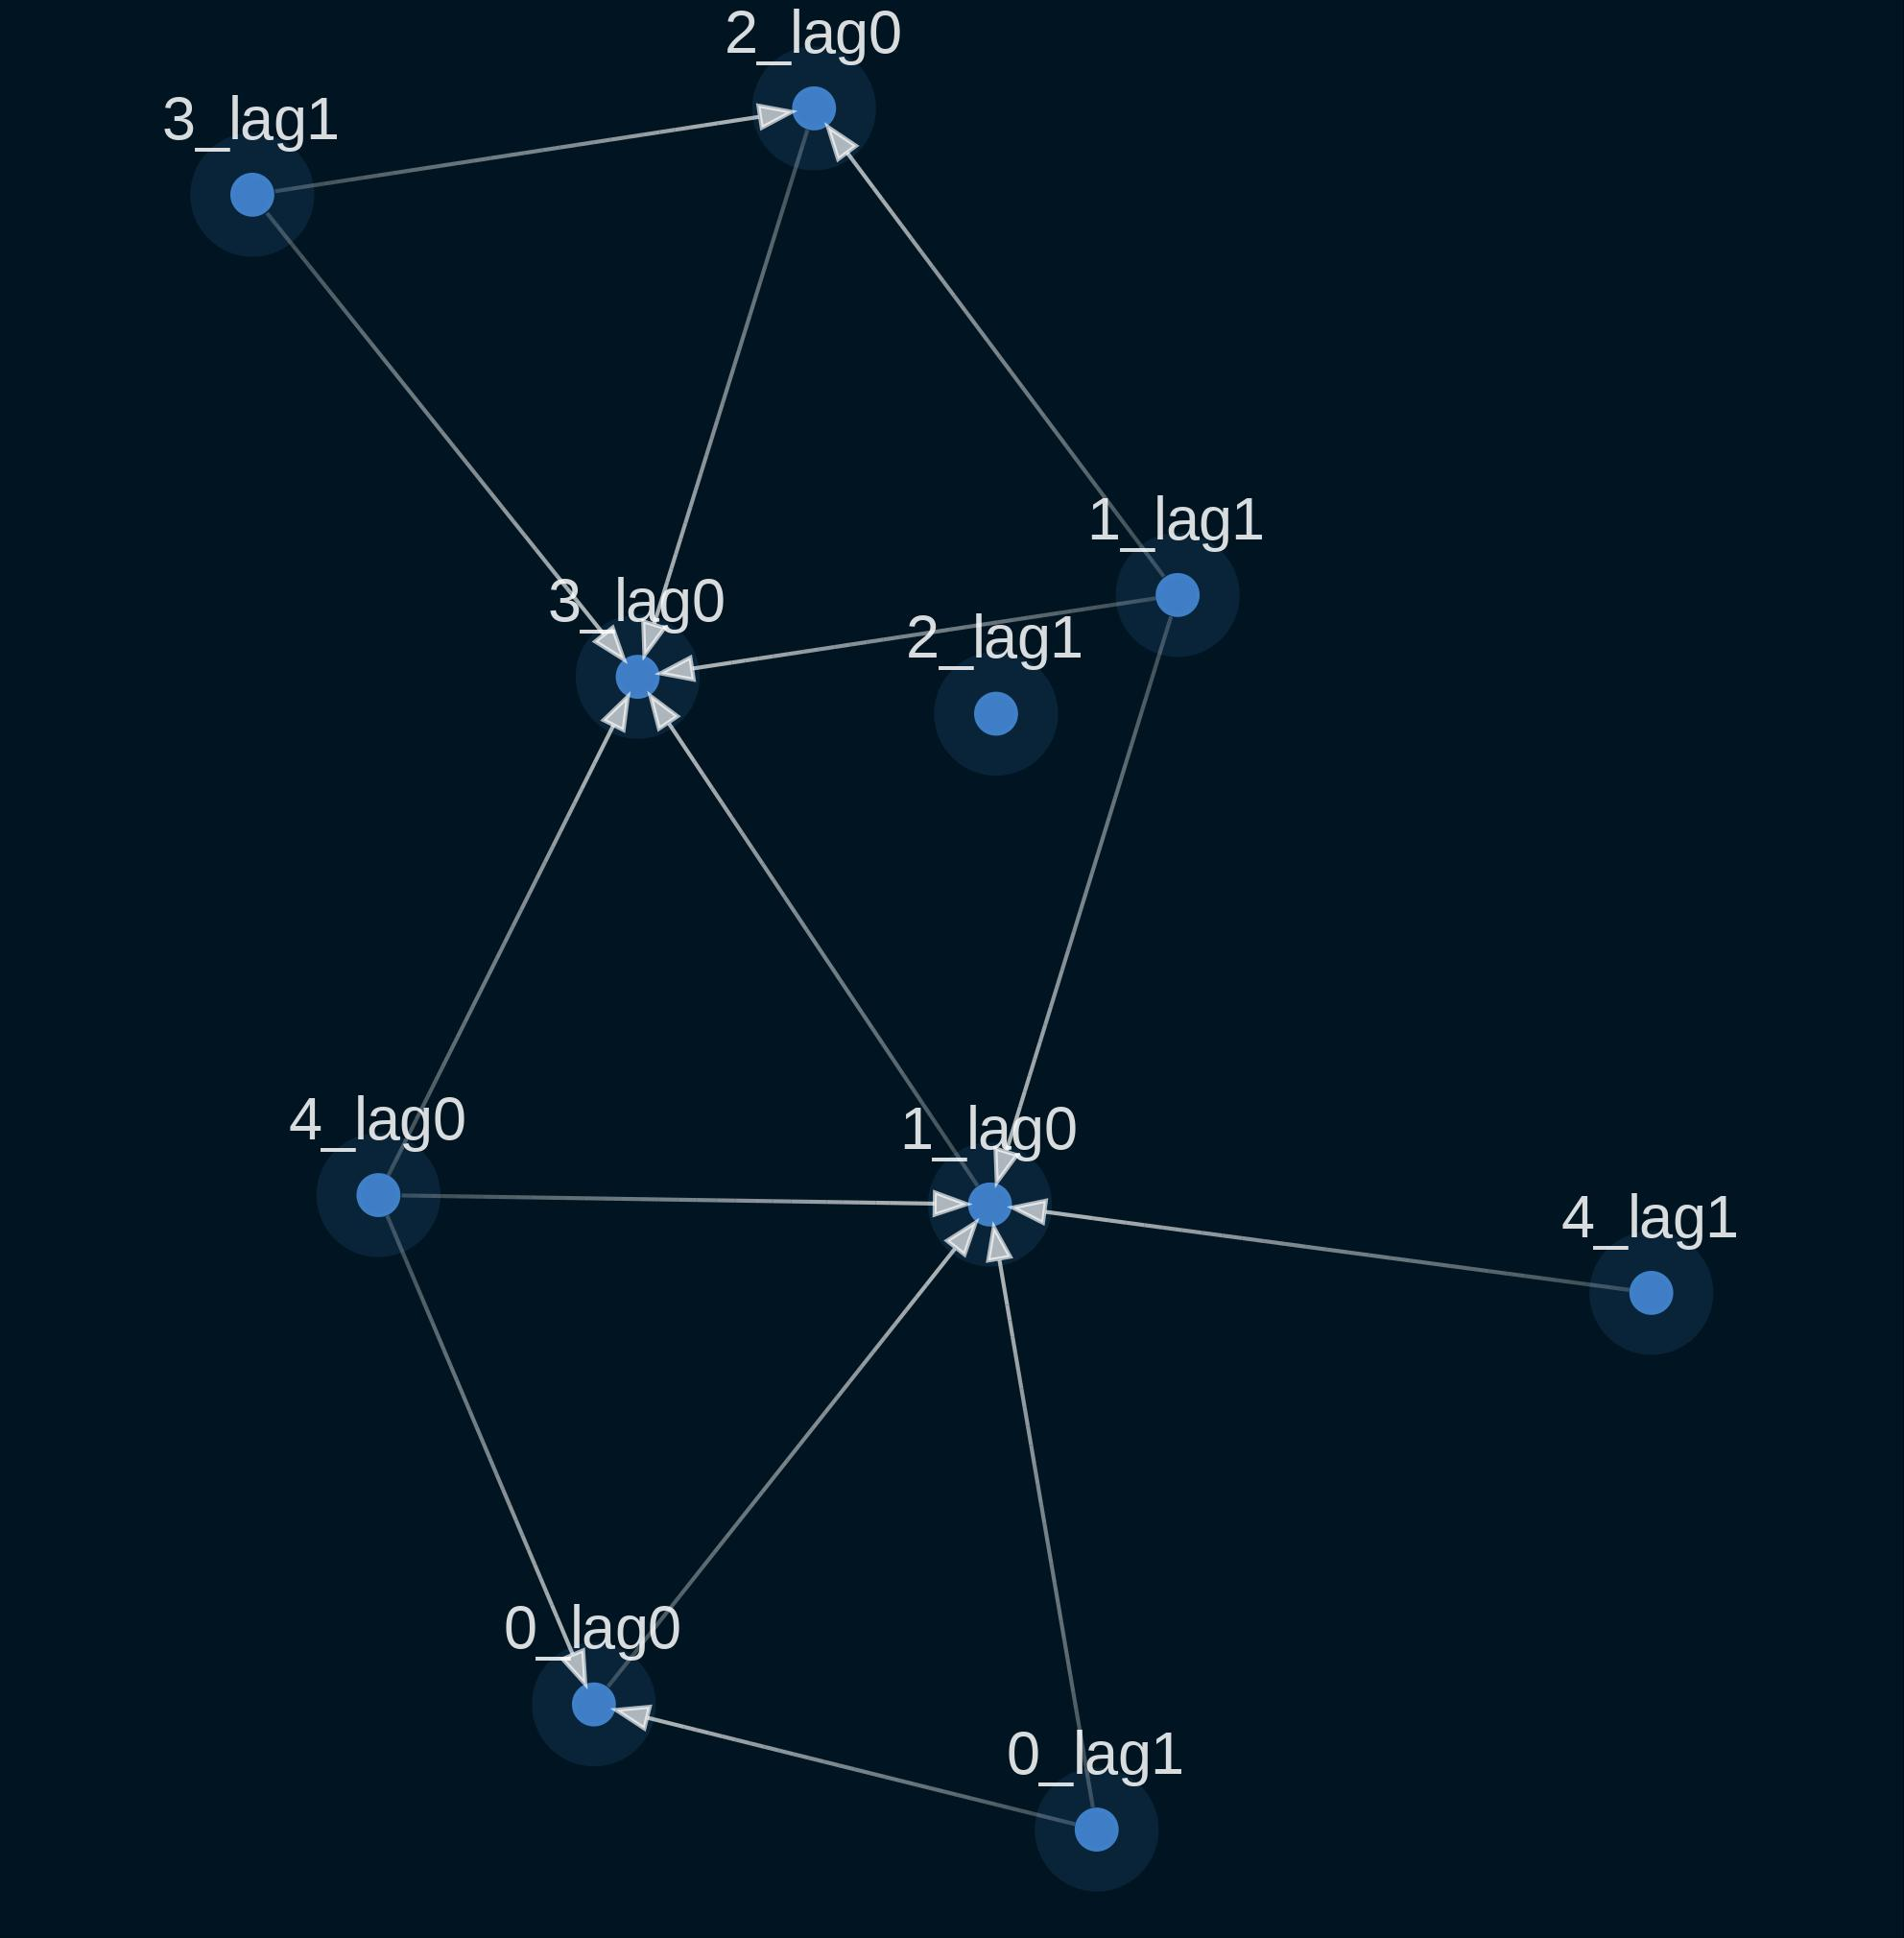

In [4]:
# then, to see the graph you can do:
from copy import deepcopy

g_learnt_2 = deepcopy(g_learnt)
g_learnt_2.remove_edges_below_threshold(0.05)


viz = plot_structure(g_learnt_2)
f = "dbn_learnt.jpg"
viz.draw(f)
Image(f)

After running this *simple* example and checking the graph below, develop an understanding of how the graph changes by going back to this block of code (or copying it and the other relevant code into a new cell) and altering the parameters (like the threshold) to see how your graph changes.

In the code above, we filtered out the weaker connections to remove some noise and get a clearer picture by setting a threshold value. Now we can see two subgraphs that appear disconnected because their connection strength is below the threshold we (somewhat arbitrarily) set. The threshold value is another parameter that you should experiment with and see how it changes the structure of the graph. Now let us look at just the largest of the subgraphs returned by the code above:<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

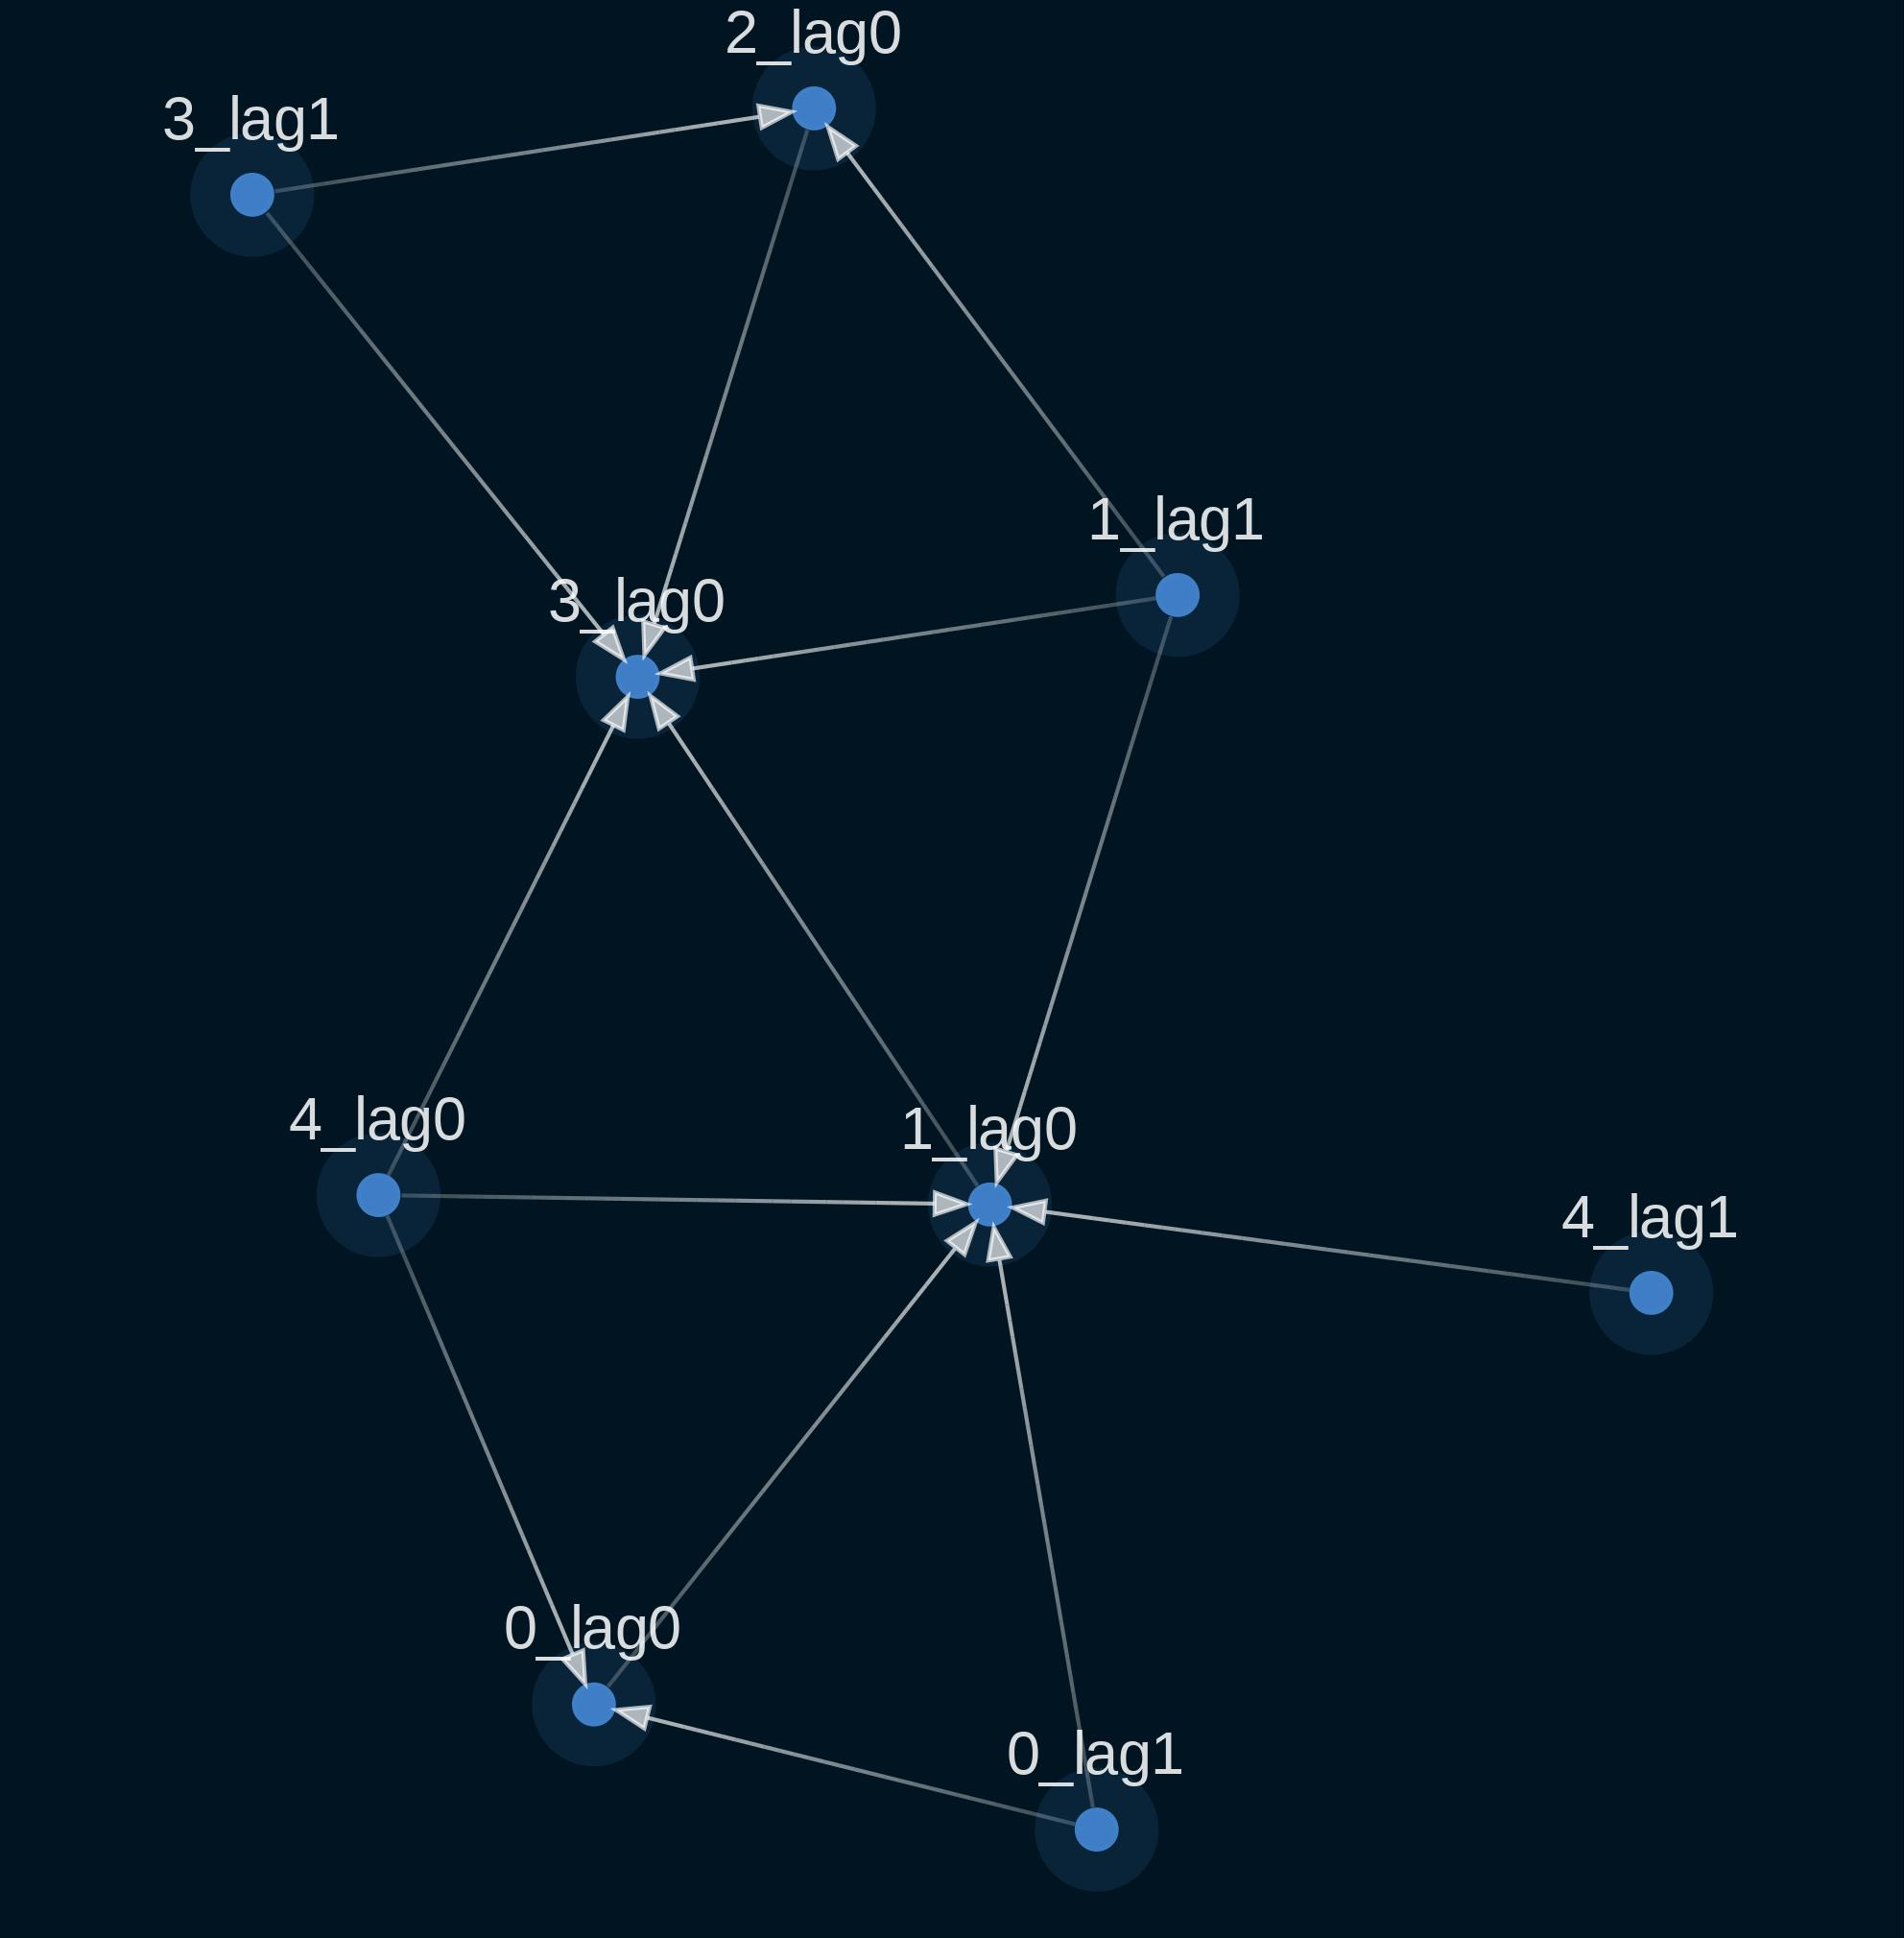

In [5]:
viz = plot_structure(g_learnt_2.get_largest_subgraph())
f = "dbn_learnt.jpg"
viz.draw(f)
Image(f)

Note that we do not see any cycles, consistent with our expectations. We also do not see any non-lag nodes with an arc directed at a lagged node; in other words, what happens *today* does not affect yesterday, which is also consistent with our expectations and traditional understanding of causality and time. We might want to see more arcs showing a lagged value impacting its present, non-lagged value, but then again, we imposed very few constraints on this simulated data that might have resulted in more realistic structure. For more realistic structure, let us now turn to real data, from the S&P 100, as was used in the paper by Pamfil et al.

## **3. Real DYNOTEARS, with S&P 100 Data**

First, we read in the list of tickers for the S&P 100 stocks (a separate .csv file) and standardize the log returns as in the paper.


In [6]:
SnP100 = pd.read_csv("SnP100.csv", header=None)
SnP100.columns = ["ticker", "company", "sector"]

# FTSE100 = pd.read_csv("FTSE100.csv", header = None)
# FTSE100.columns = ["ticker", "company", "sector"]

We can absolutely use all of the tickers, but doing so will increase the processing time it takes to learn the graph. So instead, let's restrict our view to the financials. 

In [7]:
financials = SnP100[SnP100["sector"] == "Financials"]
financials

,ticker,company,sector
5,AIG,AIG,Financials
10,AXP,American Express,Financials
12,BAC,Bank of America,Financials
13,BK,BNY Mellon,Financials
15,BLK,BlackRock,Financials
17,BRK.B,Berkshire Hathaway,Financials
18,C,Citigroup,Financials
23,COF,Capital One,Financials
45,GS,Goldman Sachs,Financials
51,JPM,JPMorgan Chase,Financials


We could absolutely use the same five-year window of data that is used in the paper by Pamfil et al. (and you should feel free to, if you have the time and processing power: it will likely take on the order of 25 minutes to run the code using that window). So for now at least, let's shorten the window that we concern ourselves with, looking just at the U.S. equities turbulence in late 2008 instead of the (commented out) range that Pamfil et al. use for their analysis. Note that there is no data for certain tickers for one reason or another: Some companies were not publicly traded during this historical window, some may have changed tickers, etc.

In [ ]:
# start_date = "2014-07-01"
# end_date = "2019-06-30"

start_date = "2008-09-01"
end_date = "2008-11-30"

daily_returns = np.log(yf.download(financials.ticker.tolist(),start_date, end_date )['Adj Close']).diff()[2:]


Got error from yahoo api for ticker BRK.B, Error: {'code': 'Not Found', 'description': 'No data found, symbol may be delisted'}


Exception in thread Thread-21:
Traceback (most recent call last):
  File "/opt/conda/lib/python3.8/threading.py", line 932, in _bootstrap_inner
    self.run()
  File "/opt/conda/lib/python3.8/threading.py", line 870, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/conda/lib/python3.8/site-packages/multitasking/__init__.py", line 104, in _run_via_pool
    return callee(*args, **kwargs)
  File "/opt/conda/lib/python3.8/site-packages/yfinance/multi.py", line 199, in _download_one_threaded
    data = _download_one(ticker, start, end, auto_adjust, back_adjust,
  File "/opt/conda/lib/python3.8/site-packages/yfinance/multi.py", line 213, in _download_one
    return Ticker(ticker).history(period=period, interval=interval,
  File "/opt/conda/lib/python3.8/site-packages/yfinance/base.py", line 153, in history
    tz = self._get_ticker_tz(debug_mode, proxy, timeout)
  File "/opt/conda/lib/python3.8/site-packages/yfinance/base.py", line 353, in _get_ticker_tz
    utils.cache_stor

Let us standardize the data as described in the paper and then check that the standard deviations (where they exist) are indeed 1.0 and the means are as close to zero as possible.

In [ ]:
# Standardize log returns
daily_returns_normd = (daily_returns - daily_returns.mean()) / daily_returns.std()
daily_returns_normd.std(), daily_returns_normd.mean()

In [ ]:
daily_returns_normd.dropna().reset_index(drop=True)

Now we can get the graph for these stocks, though it may take fifteen minutes.

In [ ]:
g_learnt_financials = from_pandas_dynamic(
    daily_returns_normd.dropna(axis=1).reset_index(drop=True),
    1,
    lambda_w=0.1,
    lambda_a=0.1,
    w_threshold=0.1,
)

In [ ]:
type(g_learnt_financials)

Technically, we do have the relevant graph for the data provided, but it is too noisy because every connection, however weak, is represented. We will make a copy of this graph and related information so that we can experiment and not ruin the original result--which would require us to re-calculate the structure information. We make a copy and delete the edges below an arbitrary 0.25 threshold. We can always very easily generate another copy of the original learned graph if we want to go back and decrease the threshold for the importance of the arcs; on the other hand, there is no need to make a new copy if we want to increase the threshold.

In [ ]:
g_learnt = deepcopy(g_learnt_financials)
g_learnt.remove_edges_below_threshold(0.15)
viz = plot_structure(g_learnt)  # .get_largest_subgraph())

f = "dbn_learnt.jpg"
viz.draw(f)
Image(f)

This is a little too busy looking, mostly due to the fact that the plot is cluttered with the nodes of several unconnected financial companies. Let's look at just the connected graph.

In [ ]:
g_learnt = deepcopy(g_learnt_financials)
g_learnt.remove_edges_below_threshold(0.15)
viz = plot_structure(g_learnt.get_largest_subgraph())

f = "dbn_learnt.jpg"
viz.draw(f)
Image(f)

This plot is still a little busy, but we notice that the lagged node for AIG influences the non-lagged AIG node, which in turn indirectly influences the returns performance of Bank of America, Wells Fargo, JPMorgan, and Citibank--the top investment and universal banks of the United States. This is consistent with what we know about AIG's centrality to the crisis that was unfolding at the time. Let's raise the threshold for the strength of the influence between nodes to further simplify our view.

In [ ]:
g_learnt = deepcopy(g_learnt_financials)
g_learnt.remove_edges_below_threshold(0.3)
viz = plot_structure(g_learnt.get_largest_subgraph())

f = "dbn_learnt.jpg"
viz.draw(f)
Image(f)

## **4. Estimated Intra-Slice Matrix**

In order to replicate the estimated intra-slice matrix that Pamfil et al. show (7), we need the full set of tickers and the five-year window as our sample. This analysis and visualization will help us understand which stocks tend to impact which stocks. This will take several minutes. 

<div class="alert alert-block alert-warning">
<b>Warning:</b> Given the amount of data being processed--the large number of tickers and the long historical window--this part could take around 30 minutes to run. If you don't have access to the required computational resources, feel free to skip the running of this code block and the rest that depend on it.
</div>


In [ ]:
start_date = "2014-07-01"
end_date = "2019-06-30"

daily_returns = np.log(yf.download(SnP100.ticker.tolist(), start_date, end_date)["Adj Close"]).diff()[2:]



# Standardize log returns
daily_returns_normd = (daily_returns - daily_returns.mean()) / daily_returns.std()

daily_returns_normd.dropna().reset_index(drop=True)

g_learnt_100 = from_pandas_dynamic(
    daily_returns_normd.dropna(axis=1).reset_index(drop=True),
    1,
    lambda_w=0.1,
    lambda_a=0.1,
    w_threshold=0.1,
)

We will need to peer into the json to extract information about the entire structure for this investigation.

In [ ]:
import pickle

In [ ]:
outfile = open("g_learnt_100", "wb")
pickle.dump(g_learnt_100, outfile)

In [ ]:
infile = open("g_learnt_100", "rb")
new_dict = pickle.load(infile)
infile.close()

In [ ]:
# print(json.dumps(dict(new_dict.adj), indent = 4, sort_keys = True))
new_dict.adj["JPM_lag0"]

We sort the stocks by the sector provided in the .csv file where we found the tickers.

In [ ]:
node_list = [node_name for node_name in new_dict.adj]
used_stocks = [stock.lower().replace("_lag0", "") for stock in node_list]
ticker_list_sorted = (
    SnP100[SnP100.ticker.str.lower().isin(used_stocks)]
    .sort_values(by="sector")
    .ticker.tolist()
)
ticker_list_sorted

In [ ]:
# Want to create matrix with values equal to source (row) to target (column) weight

# Create a list of the node names
# node_list = [ node_name for node_name in new_dict.adj ]
tickers_with_lag_suffix = [ticker + "_lag0" for ticker in ticker_list_sorted]

# Create the W matrix with initial values equal to 0
w_matrix = pd.DataFrame(
    np.zeros((len(tickers_with_lag_suffix), len(tickers_with_lag_suffix))),
    columns=tickers_with_lag_suffix,
    index=tickers_with_lag_suffix,
)

# Loop over the source stocks (arrow coming out of this node)
for source_row_stock in tqdm(tickers_with_lag_suffix):
    # source_row_stock = source_row_stock + "_lag0"
    source_row_stock_dict = new_dict.adj[source_row_stock]
    # Loop over the target stocks (nodes that source stock points to, if any)
    for target_stock in source_row_stock_dict:
        # In w_matrix, change the source/row, target/column value to the weight of that arrow
        w_matrix.loc[source_row_stock, target_stock] = source_row_stock_dict[
            target_stock
        ]["weight"]

Now we can see that, as we might expect, especially after reading the paper by Pamfil et al., that the stocks within a sector appear to have stronger causal relationships with each other.

In [ ]:
use_rows = [row for row in w_matrix.index.values if w_matrix.loc[row].max() > 0]
sns.heatmap(w_matrix.loc[use_rows], cmap="YlGnBu")

## **4. Conclusion**
In this lesson, we performed analysis of the causal structure in a specific equity market, the S&P 100, using Bayesian networks. In the next lesson, we continue to explore the usefulness of Bayesian networks by seeing how they can be put to use to estimate the probability of default for a bank.

**References:**

- Ferreira, Gabriel Azevedo. "I Have a Question about Dynotears." *GitHub*, https://github.com/quantumblacklabs/causalnex.
- Pamfil, Roxana, et al. "DYNOTEARS: Structure Learning from Time-Series Data." *arXiv*, 27 Apr 2020, https://arxiv.org/abs/2002.00498.

---
Copyright 2023 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
